In [1]:
# This file is part of SRO_related and is licensed under the GNU General Public License v3.0.
# See the LICENSE file in the root directory of this source tree or visit http://www.gnu.org/licenses/gpl-3.0.html.

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from IPython.display import clear_output
import sympy as sp

from torch import nn
from torch.functional import F
import torch

In [15]:
a, b, theta, x, y, x_d, y_d, x_std, y_std = sp.symbols(r'a b \theta x y x_d y_d \sigma_x \sigma_y')
p_raw = sp.Matrix([a*(x+x_d+x_std), b*(y+y_d+y_std)])
rotate_mat = sp.Matrix([[sp.cos(theta), -sp.sin(theta)], [sp.sin(theta), sp.cos(theta)]])
p_rot = rotate_mat * p_raw

p_fin = sp.Matrix([p_rot[0], p_rot[1]])
p_fin

Matrix([
[a*(\sigma_x + x + x_d)*cos(\theta) - b*(\sigma_y + y + y_d)*sin(\theta)],
[a*(\sigma_x + x + x_d)*sin(\theta) + b*(\sigma_y + y + y_d)*cos(\theta)]])

Compute the parameters for an ideal lattice by inputting a buffer of recognized atom centroids, assuming a square lattice configuration.

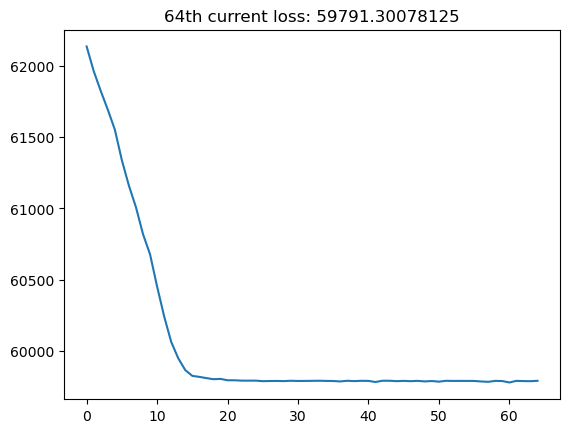

In [3]:
class model(nn.Module):
    def __init__(self, input_mat, param_list, intensity_list):
        super().__init__()

        self.weights = nn.Parameter(param_list) #* a, theta, d_x, d_y
        self.img_nonzero, self.grid_point_chosen = input_mat[:,:2], input_mat[:,2:]
        self.intensity_list = intensity_list
    
    def cart_convert(self):
        '''
        Convert grid to cartesian coordinates.
        Add noise term to the grid points.
        '''
        grid = self.grid_point_chosen
        a, theta, d_x, d_y, std_x, std_y = self.weights
        
        std_x_ = torch.randn(grid.shape[0])*std_x
        std_y_ = torch.randn(grid.shape[0])*std_y
        
        x_ = a*(grid[:,0]+std_x_)*torch.cos(theta) - a*(grid[:,1]+std_y_)*torch.sin(theta) + a*d_x
        y_ = a*(grid[:,0]+std_x_)*torch.sin(theta) + a*(grid[:,1]+std_y_)*torch.cos(theta) + a*d_y
        
        return torch.column_stack((x_, y_))
    
    def dis_calc(self):
        
        cart = self.cart_convert()
        try:
            dis = torch.linalg.norm(cart-self.img_nonzero, dim=1)*self.intensity_list
        except:
            print(cart.shape, self.img_nonzero.shape, self.intensity_list.shape)
        
        return dis
    
    def forward(self,):

        dis = self.dis_calc()
        loss = torch.sum(dis)
        
        return loss

def single_point(a, n_x, n_y, theta, d_x, d_y, 
                std_x=None, std_y=None, use_std=False, return_int=True):
    
    if use_std:
        std_x = np.random.randn(n_x.shape[0])*std_x
        std_y = np.random.randn(n_y.shape[0])*std_x
    elif not use_std:
        std_x, std_y = 0, 0
    
    x_ = a*(n_x+std_x)*np.cos(theta) - a*(n_y+std_y)*np.sin(theta) + a*d_x
    y_ = a*(n_x+std_x)*np.sin(theta) + a*(n_y+std_y)*np.cos(theta) + a*d_y
    
    xy_cart = np.column_stack((x_, y_))
    if not return_int:
        return xy_cart
    elif return_int:
        return np.column_stack((xy_cart, n_x.reshape(-1,1), n_y.reshape(-1,1))).astype(int)
          
def train(model, optimizer, scheduler, max_n, meta_i, device):
    loss_min = torch.tensor(1e10).to(device)
    # loss_list = []
    for i in range(max_n):
        loss = model.forward()
        optimizer.zero_grad()
        loss.backward(retain_graph=True)
        optimizer.step()
        scheduler.step()
        
        loss_item = loss.item()
        if loss_item < loss_min:
            loss_min = loss_item
        
        # loss_list.append(loss_item)
        # clear_output(wait=True)
        # if i % 100 == 0:
        #     plt.title(f'{meta_i}th current loss: {loss.item()}')
        #     plt.plot(loss_list)
        #     plt.show()
    
    return loss_min, model.weights.clone()
        
#* Initialize parameters
a = 19
theta = np.deg2rad(33.0)
d_x, d_y = -0.01, 0.01
std_x, std_y = 0.1, 0.1
init_param = torch.tensor([a, theta, d_x, d_y, std_x, std_y]).float()
# device = torch.device(f'cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

img_denote = 'CrCoNi-231101'
img_ind = '1' #TODO important
split_ind = ''
img_info = [img_denote, img_ind, split_ind]
# img_grid_map = np.load(f'{img_ind}/grid_calib/img_grid_map.npy')
grid_point_raw = np.load(f'{img_denote}/{img_ind}/grid_calib/grid_point_raw.npy')
n_x_raw, n_y_raw = grid_point_raw[:,0], grid_point_raw[:,1]
cart_point_raw = single_point(a, n_x_raw, n_y_raw, theta, d_x, d_y, None, None, return_int=False)
np.save(f'{img_denote}/{img_ind}/grid_calib/cart_point_raw.npy', cart_point_raw)
# img_nonzero = np.load(f'{img_denote}/{img_ind}/grid_calib/img_nonzero_recog.npy')
img_nonzero = np.load(f'{img_denote}/{img_ind}/{img_ind}_dotted-raw{split_ind}.npy')[:,-2:]

#* recog: recognized dots; raw: raw pixels with positive intensity

cart_point_filter_ind = np.where(
    (cart_point_raw[:,0]>np.min(img_nonzero[:,0])-10)
    & (cart_point_raw[:,0]<np.max(img_nonzero[:,0]+10))
    & (cart_point_raw[:,1]>np.min(img_nonzero[:,1])-10)
    & (cart_point_raw[:,1]<np.max(img_nonzero[:,1]+10)))[0]

cart_point_filter = cart_point_raw[cart_point_filter_ind]
grid_point_filter = grid_point_raw[cart_point_filter_ind]
x_res = cart_point_filter[:,0]-img_nonzero[:,0].reshape(-1,1)
y_res = cart_point_filter[:,1]-img_nonzero[:,1].reshape(-1,1)
d_res = np.sqrt(x_res**2+y_res**2)

d_full = np.vstack((d_res, np.ones((d_res.shape[1]-d_res.shape[0], d_res.shape[1]))*1e4))
min_pair = linear_sum_assignment(d_full)
# cart_chosen = cart_point_filter[min_pair[1]][:d_res.shape[0]] #* sorted by img_nonzero
grid_point_chosen = grid_point_filter[min_pair[1]][:d_res.shape[0]]

input_mat = np.column_stack((img_nonzero[:,:2], grid_point_chosen))
input_mat = torch.from_numpy(input_mat).float()

try:
    input_intensity = img_nonzero[:,2]/np.max(img_nonzero[:,2])
    input_intensity = torch.from_numpy(input_intensity).float()
except:
    input_intensity = torch.ones(input_mat.shape[0]).float()
    
#* Start meta-training
input_mat = input_mat.to(device)
init_param = init_param.to(device)  
input_intensity = input_intensity.to(device)

meta_n = 65
loss_list = []
global_loss_min = torch.tensor(1e10).to(device)
for meta_i in range(meta_n):

    #* Initialize model
    m = model(input_mat, init_param, input_intensity)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    sch = torch.optim.lr_scheduler.StepLR(opt, step_size=1000, gamma = 0.98)
    m = m.to(device)

    loss_min, weight_optimized = train(m, opt, sch, 1000, meta_i, device=device)
    
    #* Do a quasi-kmeans clustering
    weight_optimized = weight_optimized.detach().cpu().numpy()
    a_opt, theta_opt, d_x_opt, d_y_opt, std_x_opt, std_y_opt = weight_optimized
    n_x_raw, n_y_raw = grid_point_raw[:,0], grid_point_raw[:,1]
    cart_point_raw = single_point(a_opt, n_x_raw, n_y_raw, 
                                  theta_opt, d_x_opt, d_y_opt, 
                                  None, None, return_int=False)
    
    cart_point_filter_ind = np.where(
        (cart_point_raw[:,0]>np.min(img_nonzero[:,0])-10)
        & (cart_point_raw[:,0]<np.max(img_nonzero[:,0]+10))
        & (cart_point_raw[:,1]>np.min(img_nonzero[:,1])-10)
        & (cart_point_raw[:,1]<np.max(img_nonzero[:,1]+10)))[0]
    
    cart_point_filter = cart_point_raw[cart_point_filter_ind]
    grid_point_filter = grid_point_raw[cart_point_filter_ind]
    x_res = cart_point_filter[:,0]-img_nonzero[:,0].reshape(-1,1)
    y_res = cart_point_filter[:,1]-img_nonzero[:,1].reshape(-1,1)
    d_res = np.sqrt(x_res**2+y_res**2)

    d_full = np.vstack((d_res, np.ones((d_res.shape[1]-d_res.shape[0], d_res.shape[1]))*1e4))
    min_pair = linear_sum_assignment(d_full)
    cart_chosen = cart_point_filter[min_pair[1]][:d_res.shape[0]] #* sorted by img_nonzero
    grid_chosen = grid_point_filter[min_pair[1]][:d_res.shape[0]]
    
    # np.save(f'{img_denote}/{img_ind}/grid_calib/cart_point_raw.npy', cart_point_filter)
    # img_grid_map = np.array(migm.process_img(img_info, n_cores=n_cores))
    
    init_param = m.weights.clone()
    input_mat = np.column_stack((img_nonzero[:,:2], grid_chosen))
    input_mat = torch.from_numpy(input_mat).float().to(device)
    
    if loss_min < global_loss_min:
        global_loss_min = loss_min
        weight_optimized_best = init_param.detach().cpu().numpy()
        cart_point_filter_best = cart_chosen.copy()
        grid_point_filter_best = grid_chosen.copy()
        ind_best = cart_point_filter_ind[min_pair[1][:d_res.shape[0]]].copy()
        # img_grid_map_best = img_grid_map.copy()
    
    clear_output(wait=True)
    loss_list.append(loss_min)
    plt.title(f'{meta_i}th current loss: {loss_min}')
    plt.plot(loss_list)
    plt.show()
    
    del d_full, d_res, x_res, y_res, cart_point_filter, cart_point_filter_ind, grid_chosen
    

Main for precise info derivation.

In [4]:
# img_grid_map, grid_img_map = migm.process_img(n_cores=n_cores)
# img_grid_map = np.array(img_grid_map)
# grid_img_map = np.array(grid_img_map)

# #* Convert weights to numpy array
# weight_optimized_best = m.weights.detach().cpu().numpy()
a_opt, theta_opt, d_x_opt, d_y_opt, std_x_opt, std_y_opt = weight_optimized_best

n_x_raw, n_y_raw = grid_point_raw[:,0], grid_point_raw[:,1]
point_mat = single_point(a_opt, n_x_raw, n_y_raw, theta_opt, d_x_opt, d_y_opt, 
                         None, None, use_std=False, return_int=False)

#* Define parameters for plotting the grids
img_denote = 'CrCoNi-231101'
img_ind = '1' #TODO important
split_ind = ''

pth_load = f'{img_denote}/{img_ind}/{img_ind}_dotted-raw{split_ind}.png'
img = cv2.imread(pth_load, cv2.IMREAD_GRAYSCALE)
inv_ = True #TODO if invert the image
inv_denote = '' 
if inv_:
    inv_denote = '_inv'
    img = cv2.bitwise_not(img)
# img_nonzero = np.load(f'{img_denote}/{img_ind}/grid_calib/img_nonzero_recog.npy')
img_nonzero = np.load(f'{img_denote}/{img_ind}/{img_ind}_dotted-raw{split_ind}.npy')[:,-2:]

radius = 2
color = (0, 0, 255)
thickness = 2
alpha=0.4
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
overlay = img_color.copy()

vec_space = []
for i in range(cart_point_filter_best.shape[0]):
    img_dot = img_nonzero[i].astype(int)
    grid_dot = cart_point_filter_best[i].astype(int)
    cv2.line(img_color, (grid_dot[1], grid_dot[0]), 
             (img_dot[1], img_dot[0]), color, thickness)
    vec = img_dot-grid_dot
    grid_dot_raw = grid_point_filter_best[i].astype(int)
    vec_info = np.concatenate((grid_dot_raw, vec, grid_dot))
    vec_space.append(vec_info)

np.save(f'{img_denote}/{img_ind}/grid_calib/vec_space.npy', vec_space)

for count, (x, y) in enumerate(point_mat):
    x, y = int(x), int(y)
    if count in ind_best:
        cv2.circle(img_color, (y,x), radius, color, thickness)
    else:
        cv2.circle(img_color, (y,x), radius=1, color=(0,0,255), thickness=1)
    
cv2.addWeighted(overlay, alpha, img_color, 1-alpha, 0, img_color)
pth_sav_fin = f'{img_denote}/{img_ind}/grid_calib/{img_ind}_opt_recog{inv_denote}.bmp'
cv2.imwrite(pth_sav_fin, img_color)
np.save(f'{img_denote}/{img_ind}/{img_ind}_dotted-raw{split_ind}_calib.npy',
        cart_point_filter_best)

print(a_opt, np.rad2deg(theta_opt), d_x_opt, d_y_opt, 
      std_x_opt, std_y_opt, loss_list[-1])

print(pth_sav_fin)

18.893955 33.20009 0.582749 -0.09505314 0.0017811599 -0.00081668765 59791.30078125
CrCoNi-231101/1/grid_calib/1_opt_recog_inv.bmp
